In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

df = pd.read_csv('../Project_description_and_data/claims_train.csv')

df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)

df['VehAge_1']    = df['VehAge'] + 1
df['VehAge_log']  = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])

pca_features = ['DrivAge_log','VehPower','VehAge_log','Density_log','BonusMalus']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

for i in range(3):
    df[f'PC{i+1}'] = X_pca[:, i]

cat_cols = ['VehBrand', 'Area', 'Region', 'VehGas']
for c in cat_cols:
    df[c] = df[c].astype('category')

df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
df['VehPower_DensityLog'] = df['VehPower'] * df['Density_log']
df['VehAgeLog_Brand'] = df['VehAge_log'] * df['VehBrand'].cat.codes
df['BonusMalus_Exposure'] = df['BonusMalus'] * df['Exposure_adj']
df['VehPower_VehGas'] = df['VehPower'] * df['VehGas'].cat.codes

interaction_features = [
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'VehAgeLog_Brand',
    'BonusMalus_Exposure',
    'VehPower_VehGas']

features = ['VehBrand', 'Region', 'PC1', 'PC2', 'PC3'] + interaction_features

X = df[features]
y = df['ClaimNb']
weights = df['Exposure_adj']


X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, weights, test_size=0.2, random_state=42)


param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [300, 600],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]}


base_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=42)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1)

grid.fit(
    X_train,
    y_train,
    sample_weight=w_train)

print("Best parameters:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

best_model = grid.best_estimator_

best_model.fit(
    X_train,
    y_train,
    sample_weight=w_train)

df_test = pd.read_csv('../Project_description_and_data/claims_test.csv')

df_test['Exposure_adj'] = df_test['Exposure'].clip(upper=1.0)

df_test['VehAge_1']    = df_test['VehAge'] + 1
df_test['VehAge_log']  = np.log(df_test['VehAge_1'])
df_test['DrivAge_log'] = np.log(df_test['DrivAge'])
df_test['Density_log'] = np.log(df_test['Density'])

X_test_scaled = scaler.transform(df_test[pca_features])
X_test_pca = pca.transform(X_test_scaled)

for i in range(3):
    df_test[f'PC{i+1}'] = X_test_pca[:, i]

for c in cat_cols:
    df_test[c] = df_test[c].astype('category')

df_test['DrivAgeLog_BonusMalus'] = df_test['DrivAge_log'] * df_test['BonusMalus']
df_test['VehPower_DensityLog'] = df_test['VehPower'] * df_test['Density_log']
df_test['VehAgeLog_Brand'] = df_test['VehAge_log'] * df_test['VehBrand'].cat.codes
df_test['BonusMalus_Exposure'] = df_test['BonusMalus'] * df_test['Exposure_adj']
df_test['VehPower_VehGas'] = df_test['VehPower'] * df_test['VehGas'].cat.codes

X_test_final = df_test[features]
y_test_final = df_test['ClaimNb']
w_test_final = df_test['Exposure_adj']

test_pred = best_model.predict(X_test_final)

test_mse = mean_squared_error(
    y_test_final,
    test_pred,
    sample_weight=w_test_final)

test_mae = mean_absolute_error(
    y_test_final,
    test_pred,
    sample_weight=w_test_final)

print("TEST MSE:", test_mse)
print("TEST MAE:", test_mae)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.9}
Best CV MSE: 0.06585600697537834
TEST MSE: 0.06777578128798126
TEST MAE: 0.11746456473763418


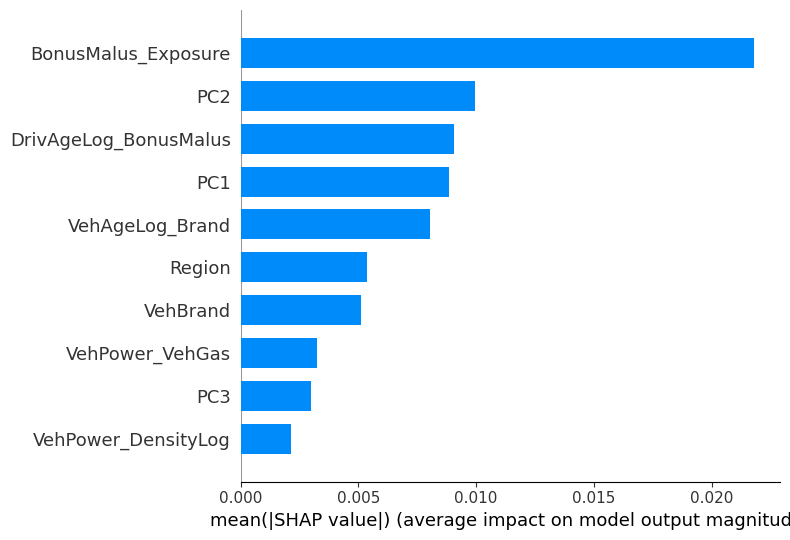

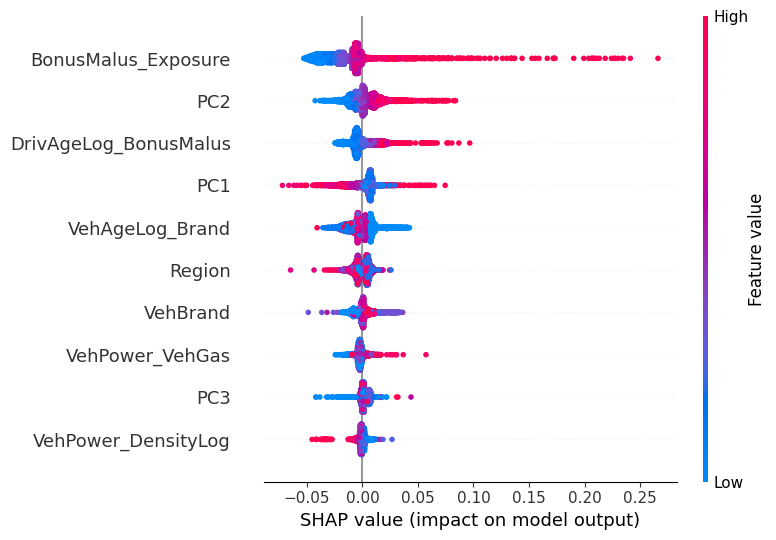

In [11]:
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

shap.initjs()

X_shap = X_train.sample(
    n=min(5000, len(X_train)),
    random_state=42
)

for c in X_shap.select_dtypes(include="category").columns:  # Convert categorical columns to codes for SHAP
    X_shap[c] = X_shap[c].cat.codes


dmat = xgb.DMatrix(X_shap, enable_categorical=True)

booster = best_model.get_booster()

shap_contribs = booster.predict(dmat, pred_contribs=True)

shap_values = shap_contribs[:, :-1]  # Last column = bias (expected value)
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)
shap.summary_plot(shap_values, X_shap, show=True)

<Figure size 1000x1200 with 0 Axes>

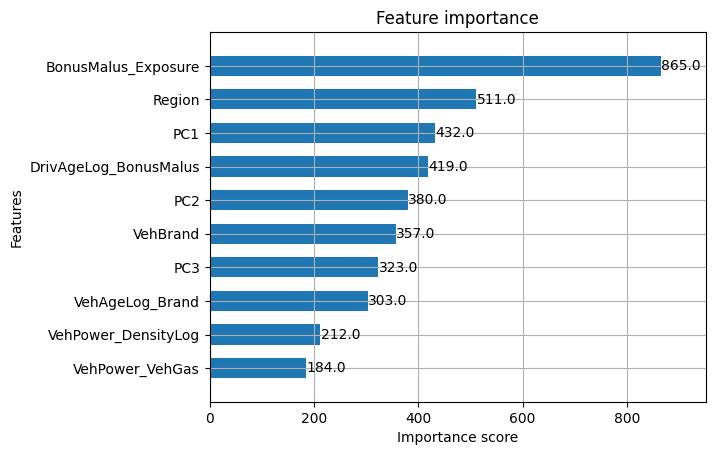

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Built-in importance plot
plt.figure(figsize=(10, 12))
plot_importance(best_model, max_num_features=30, height=0.6)
plt.show()